# MVP v0.2.5.10: Action Distribution Diversity Diagnostics

**Date:** 2026-03-17
**Builds on:** v0.2.5.9 (BC_Gaussian scorers, cos=0.54, rho=0.21 FAIL)

## Motivation

v0.2.5.6–9 all failed because policy scorers produce similar gradients (cos ~0.5–0.7).
Before trying more guidance fixes, we need to **measure how similar the action
distributions actually are** and compare against a known-working setting (D4RL).

## Four Diagnostics

1. **Per-state KL divergence** — analytic KL between BC_Gaussian pairs, conditioned on same states
2. **D4RL calibration** — train BC_Gaussian on hopper-{random,medium,expert} and compute the same metrics. Gives a "passing threshold" from a setting where policies are genuinely diverse.
3. **Action marginal overlap** — Wasserstein-1 distance per action dim between policy pairs
4. **Policy identity classifier** — MLP that predicts which policy generated a (state, action). Chance = 1/N. High accuracy = distinguishable distributions.

## Success criterion
If Lift policies are as distinguishable as D4RL policies on these metrics, the problem is in guidance implementation, not data. If Lift is much less distinguishable, we know guidance-based OPE fundamentally won't work on this task.

In [1]:
%matplotlib inline
import sys, os, math, time, json, warnings
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from scipy.stats import wasserstein_distance

warnings.filterwarnings("ignore", category=DeprecationWarning)

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
OBS_KEYS = sorted(["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"])

# Dims
STATE_DIM = 19
ACTION_DIM = 7

# BC_Gaussian training config
BC_HIDDEN_DIMS = [256, 256]
BC_LR = 1e-4
BC_BATCH_SIZE = 256

print("Setup complete")

Device: cuda
Setup complete


In [2]:
# ── GaussianPolicy (same as v0.2.5.9) ──
class GaussianPolicy(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dims=[256, 256],
                 init_std=0.3, min_std=0.01, max_std=7.5):
        super().__init__()
        self.obs_dim = obs_dim
        self.action_dim = action_dim
        self.min_std = min_std
        self.max_std = max_std
        layers = []
        in_dim = obs_dim
        for h in hidden_dims:
            layers.extend([nn.Linear(in_dim, h), nn.ReLU()])
            in_dim = h
        self.backbone = nn.Sequential(*layers)
        self.mean_head = nn.Linear(in_dim, action_dim)
        self.log_std_head = nn.Linear(in_dim, action_dim)
        init_bias = np.log(np.exp(init_std) - 1.0)
        nn.init.constant_(self.log_std_head.bias, init_bias)
        nn.init.zeros_(self.log_std_head.weight)

    def forward(self, obs):
        h = self.backbone(obs)
        mean = self.mean_head(h)
        std = torch.clamp(F.softplus(self.log_std_head(h)), min=self.min_std, max=self.max_std)
        return mean, std

    def log_prob(self, obs, action):
        mean, std = self.forward(obs)
        return torch.distributions.Normal(mean, std).log_prob(action).sum(-1)

    @torch.no_grad()
    def grad_log_prob(self, obs, action):
        mean, std = self.forward(obs)
        return -(action - mean) / (std ** 2)

    @torch.no_grad()
    def sample_actions(self, obs):
        mean, std = self.forward(obs)
        return mean + std * torch.randn_like(mean)

    def train_on_data(self, obs, actions, n_epochs, batch_size=256, lr=1e-4):
        opt = torch.optim.Adam(self.parameters(), lr=lr)
        dev = next(self.parameters()).device
        obs_t = torch.tensor(obs, dtype=torch.float32, device=dev)
        act_t = torch.tensor(actions, dtype=torch.float32, device=dev)
        N = len(obs_t)
        steps_per_epoch = max(1, N // batch_size)
        self.train()
        losses = []
        for epoch in range(n_epochs):
            epoch_loss = 0.0
            perm = torch.randperm(N, device=dev)
            for step in range(steps_per_epoch):
                idx = perm[step * batch_size:(step + 1) * batch_size]
                if len(idx) == 0: continue
                nll = -self.log_prob(obs_t[idx], act_t[idx]).mean()
                opt.zero_grad(); nll.backward(); opt.step()
                epoch_loss += nll.item()
            losses.append(epoch_loss / max(1, steps_per_epoch))
        self.eval()
        return losses

print("GaussianPolicy defined")

GaussianPolicy defined


In [3]:
# ── Load Lift demo data & train BC_Gaussian policies ──
def load_demos(hdf5_path, filter_key=None, obs_keys=None):
    all_obs, all_acts = [], []
    with h5py.File(hdf5_path, "r") as f:
        if filter_key is not None:
            demo_keys = [k.decode() if isinstance(k, bytes) else k
                         for k in f[f"mask/{filter_key}"][:]]
        else:
            demo_keys = sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1]))
        for dk in demo_keys:
            demo = f[f"data/{dk}"]
            obs = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in obs_keys], axis=-1)
            acts = demo["actions"][:].astype(np.float32)
            all_obs.append(obs)
            all_acts.append(acts)
    return np.concatenate(all_obs, axis=0), np.concatenate(all_acts, axis=0)

TARGETS = [
    {"name": "bc_10demos_e50",   "filter_key": "10_demos",  "epochs": 50},
    {"name": "bc_10demos_e200",  "filter_key": "10_demos",  "epochs": 200},
    {"name": "bc_25demos_e100",  "filter_key": "25_demos",  "epochs": 100},
    {"name": "bc_50demos_e100",  "filter_key": "50_demos",  "epochs": 100},
    {"name": "bc_100demos_e100", "filter_key": "100_demos", "epochs": 100},
    {"name": "bc_200demos_e100", "filter_key": None,         "epochs": 100},
]

target_data = {}
for tgt in TARGETS:
    obs, acts = load_demos(DEMO_HDF5, tgt["filter_key"], OBS_KEYS)
    target_data[tgt["name"]] = {"obs": obs, "actions": acts}
    print(f"{tgt['name']:<22} {len(obs):>6} transitions")

print(f"\nTraining BC_Gaussian policies...")
bc_policies = {}
names = [t["name"] for t in TARGETS]

for tgt in TARGETS:
    name = tgt["name"]
    data = target_data[name]
    print(f"  {name:<22}", end=" ", flush=True)
    t0 = time.time()
    policy = GaussianPolicy(STATE_DIM, ACTION_DIM, hidden_dims=BC_HIDDEN_DIMS).to(device)
    losses = policy.train_on_data(data["obs"], data["actions"],
                                   n_epochs=tgt["epochs"], batch_size=BC_BATCH_SIZE, lr=BC_LR)
    bc_policies[name] = policy
    print(f"loss={losses[-1]:.4f}, {time.time()-t0:.0f}s")

# Common test batch (from full 200-demo dataset)
test_obs_np = target_data["bc_200demos_e100"]["obs"][:500]
test_act_np = target_data["bc_200demos_e100"]["actions"][:500]
test_obs_t = torch.tensor(test_obs_np, dtype=torch.float32, device=device)
print(f"\nTest batch: {test_obs_t.shape[0]} states")

bc_10demos_e50            511 transitions
bc_10demos_e200           511 transitions
bc_25demos_e100          1218 transitions
bc_50demos_e100          2447 transitions
bc_100demos_e100         4898 transitions


bc_200demos_e100         9666 transitions

Training BC_Gaussian policies...
  bc_10demos_e50         

loss=3.2661, 2s
  bc_10demos_e200        

loss=-4.1362, 0s
  bc_25demos_e100        

loss=-4.3242, 1s
  bc_50demos_e100        

loss=-4.7929, 1s
  bc_100demos_e100       

loss=-5.8774, 3s
  bc_200demos_e100       

loss=-7.4191, 5s

Test batch: 500 states


## Diagnostic 1: Per-State KL Divergence

For two Gaussians $\pi_i(a|s) = \mathcal{N}(\mu_i(s), \sigma_i(s))$ and $\pi_j(a|s) = \mathcal{N}(\mu_j(s), \sigma_j(s))$:

$$\text{KL}(\pi_i \| \pi_j | s) = \sum_d \left[ \log\frac{\sigma_{j,d}}{\sigma_{i,d}} + \frac{\sigma_{i,d}^2 + (\mu_{i,d} - \mu_{j,d})^2}{2\sigma_{j,d}^2} - \frac{1}{2} \right]$$

- KL < 1: nearly indistinguishable
- KL ~ 1-5: moderate difference  
- KL > 10: very different policies

DIAGNOSTIC 1: Per-State KL Divergence (Lift BC_Gaussian policies)

Mean KL(pi_i || pi_j) over 500 test states:
                           bc_10dem  bc_10dem  bc_25dem  bc_50dem  bc_100de  bc_200de
   bc_10demos_e50             0.000    64.869    98.687   124.915   143.587   201.310
   bc_10demos_e200            6.805     0.000     0.893     2.014     3.528    30.113
   bc_25demos_e100            7.054     0.951     0.000     0.639     1.930    27.095
   bc_50demos_e100            7.163     1.681     0.495     0.000     0.875    19.389
   bc_100demos_e100           7.540     2.058     1.119     0.566     0.000     7.090
   bc_200demos_e100           8.807     3.947     3.000     2.225     1.367     0.000

Lift mean pairwise KL: 48.462 (range: [0.639, 201.310])
>> HIGH: policies are well-separated


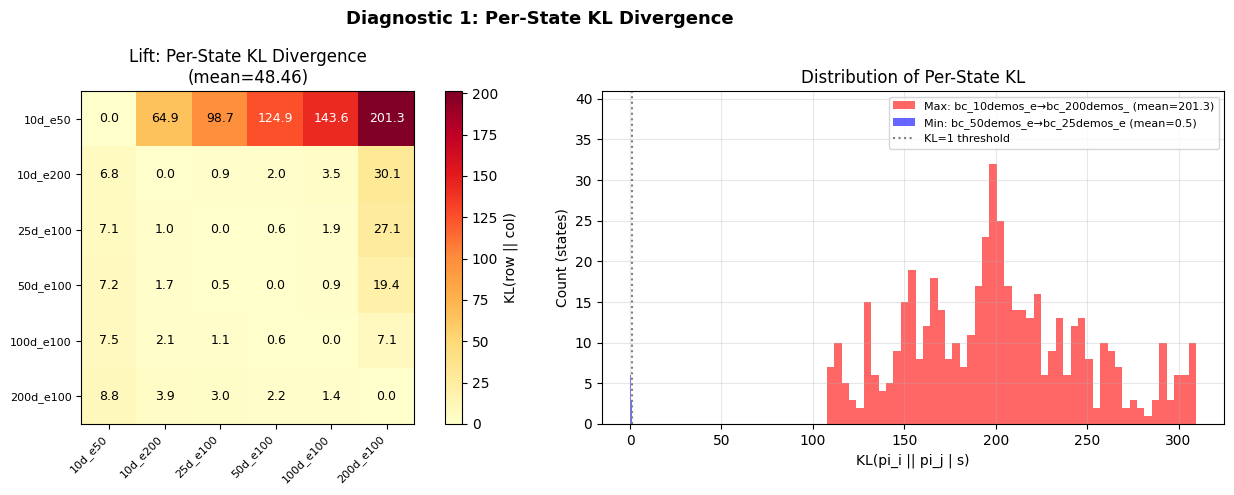

In [4]:
# ── Diagnostic 1: Per-state KL divergence ──
@torch.no_grad()
def pairwise_kl(pol_i, pol_j, obs_t):
    """Analytic KL(pi_i || pi_j | s) for Gaussians, averaged over states."""
    mu_i, std_i = pol_i(obs_t)
    mu_j, std_j = pol_j(obs_t)
    # KL per dim: log(std_j/std_i) + (std_i^2 + (mu_i - mu_j)^2) / (2*std_j^2) - 0.5
    kl_per_dim = (torch.log(std_j / std_i)
                  + (std_i**2 + (mu_i - mu_j)**2) / (2 * std_j**2)
                  - 0.5)
    kl_per_state = kl_per_dim.sum(-1)  # (B,)
    return kl_per_state.cpu().numpy()

n_pol = len(names)
kl_matrix_mean = np.zeros((n_pol, n_pol))
kl_matrix_median = np.zeros((n_pol, n_pol))
kl_all_pairs = {}

print(f"{'='*80}")
print(f"DIAGNOSTIC 1: Per-State KL Divergence (Lift BC_Gaussian policies)")
print(f"{'='*80}\n")

print(f"Mean KL(pi_i || pi_j) over {test_obs_t.shape[0]} test states:")
print(f"   {'':>22}", end="")
for n in names:
    print(f" {n[:8]:>9}", end="")
print()

for i, n1 in enumerate(names):
    print(f"   {n1:<22}", end="")
    for j, n2 in enumerate(names):
        if i == j:
            kl_matrix_mean[i, j] = 0.0
            kl_matrix_median[i, j] = 0.0
            print(f" {'0.000':>9}", end="")
        else:
            kl_vals = pairwise_kl(bc_policies[n1], bc_policies[n2], test_obs_t)
            kl_matrix_mean[i, j] = kl_vals.mean()
            kl_matrix_median[i, j] = np.median(kl_vals)
            kl_all_pairs[(n1, n2)] = kl_vals
            print(f" {kl_vals.mean():>9.3f}", end="")
    print()

# Summary stats
off_diag = []
for i in range(n_pol):
    for j in range(i+1, n_pol):
        off_diag.append(kl_matrix_mean[i, j])
lift_kl_mean = np.mean(off_diag)
lift_kl_min = np.min(off_diag)
lift_kl_max = np.max(off_diag)

print(f"\nLift mean pairwise KL: {lift_kl_mean:.3f} (range: [{lift_kl_min:.3f}, {lift_kl_max:.3f}])")
if lift_kl_mean < 1.0:
    print(">> LOW: policies are nearly indistinguishable (KL < 1)")
elif lift_kl_mean < 5.0:
    print(">> MODERATE: some differentiation")
else:
    print(">> HIGH: policies are well-separated")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
ax = axes[0]
short = [n.replace("bc_", "").replace("demos_", "d_") for n in names]
im = ax.imshow(kl_matrix_mean, cmap="YlOrRd", vmin=0)
ax.set_xticks(range(n_pol)); ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(n_pol)); ax.set_yticklabels(short, fontsize=8)
for i in range(n_pol):
    for j in range(n_pol):
        color = "white" if kl_matrix_mean[i, j] > kl_matrix_mean.max() * 0.6 else "black"
        ax.text(j, i, f"{kl_matrix_mean[i,j]:.1f}", ha="center", va="center",
                color=color, fontsize=9)
plt.colorbar(im, ax=ax, label="KL(row || col)")
ax.set_title(f"Lift: Per-State KL Divergence\n(mean={lift_kl_mean:.2f})")

# Histogram of per-state KL for most different pair
ax = axes[1]
max_pair = max(kl_all_pairs.items(), key=lambda x: x[1].mean())
min_pair = min(kl_all_pairs.items(), key=lambda x: x[1].mean())
ax.hist(max_pair[1], bins=50, alpha=0.6, color="red",
        label=f"Max: {max_pair[0][0][:12]}→{max_pair[0][1][:12]} (mean={max_pair[1].mean():.1f})")
ax.hist(min_pair[1], bins=50, alpha=0.6, color="blue",
        label=f"Min: {min_pair[0][0][:12]}→{min_pair[0][1][:12]} (mean={min_pair[1].mean():.1f})")
ax.axvline(x=1.0, color="gray", ls=":", label="KL=1 threshold")
ax.set_xlabel("KL(pi_i || pi_j | s)")
ax.set_ylabel("Count (states)")
ax.set_title("Distribution of Per-State KL")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle("Diagnostic 1: Per-State KL Divergence", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Diagnostic 2: D4RL Calibration

Train BC_Gaussian policies on D4RL hopper data from **different dataset types** (random, medium, expert).
These are genuinely different behavior distributions, so they establish a "passing" baseline
for KL, Wasserstein, cosine, and classifier accuracy.

- `hopper-random-v2`: random policy data
- `hopper-medium-v2`: medium-quality policy data  
- `hopper-expert-v2`: expert policy data

If SOPE works on D4RL, these policies should show much higher diversity than our Lift policies.

In [5]:
# ── Diagnostic 2: D4RL Calibration ──
import gym
import d4rl

D4RL_ENVS = [
    ("hopper-random-v2",  100),   # random policy data, 100 epochs
    ("hopper-medium-v2",  100),   # medium policy data
    ("hopper-expert-v2",  100),   # expert policy data
]

# Also add subsets of medium to test within-dataset variation (like our Lift experiment)
D4RL_MEDIUM_SUBSETS = [
    ("medium_1k",   1000,  100),  # 1k transitions from medium
    ("medium_10k",  10000, 100),  # 10k transitions from medium
    ("medium_100k", 100000, 100), # 100k transitions from medium
]

d4rl_data = {}
d4rl_policies = {}

# Load D4RL datasets
print("Loading D4RL datasets...")
for env_name, epochs in D4RL_ENVS:
    env = gym.make(env_name)
    dataset = d4rl.qlearning_dataset(env)
    obs = dataset["observations"].astype(np.float32)
    acts = dataset["actions"].astype(np.float32)
    short_name = env_name.replace("hopper-", "").replace("-v2", "")
    d4rl_data[short_name] = {"obs": obs, "actions": acts}
    print(f"  {short_name:<12} {len(obs):>8} transitions, obs={obs.shape[-1]}, act={acts.shape[-1]}")
    env.close()

D4RL_OBS_DIM = d4rl_data["random"]["obs"].shape[-1]  # 11
D4RL_ACT_DIM = d4rl_data["random"]["actions"].shape[-1]  # 3

# Add medium subsets
for sub_name, n_trans, epochs in D4RL_MEDIUM_SUBSETS:
    full = d4rl_data["medium"]
    idx = np.random.RandomState(42).permutation(len(full["obs"]))[:n_trans]
    d4rl_data[sub_name] = {"obs": full["obs"][idx], "actions": full["actions"][idx]}

# Train BC_Gaussian on each
print(f"\nTraining D4RL BC_Gaussian policies (obs={D4RL_OBS_DIM}, act={D4RL_ACT_DIM})...")
d4rl_names = ["random", "medium", "expert", "medium_1k", "medium_10k", "medium_100k"]
d4rl_epochs = {"random": 100, "medium": 100, "expert": 100,
               "medium_1k": 100, "medium_10k": 100, "medium_100k": 100}

for name in d4rl_names:
    data = d4rl_data[name]
    n_ep = d4rl_epochs[name]
    print(f"  {name:<14}", end=" ", flush=True)
    t0 = time.time()
    pol = GaussianPolicy(D4RL_OBS_DIM, D4RL_ACT_DIM, hidden_dims=BC_HIDDEN_DIMS).to(device)
    losses = pol.train_on_data(data["obs"], data["actions"],
                                n_epochs=n_ep, batch_size=BC_BATCH_SIZE, lr=BC_LR)
    d4rl_policies[name] = pol
    print(f"loss={losses[-1]:.4f}, {time.time()-t0:.0f}s")

# Common test batch (from medium dataset)
d4rl_test_obs = torch.tensor(d4rl_data["medium"]["obs"][:500], dtype=torch.float32, device=device)
d4rl_test_act = torch.tensor(d4rl_data["medium"]["actions"][:500], dtype=torch.float32, device=device)
print(f"\nD4RL test batch: {d4rl_test_obs.shape}")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
These new versions include large bug fixes, new versions of Python, and are where all new development will continue. Please upgrade these libraries as soon as you're able to do so.
If you'd like to read more about the story behind this switch, please check out ]8;;https://farama.org/Announcing-Minari\this blog post]8;;\.
/home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/Cython/Distutils/old_build_ext.py:15: DeprecationWarning: dep_util is Deprecated. Use functions from setuptools instead.
  from distutils.dep_util import newer, newer_group


<frozen importlib._bootstrap>:283: DeprecationWarning: the load_module() method is deprecated and slated for removal in Python 3.12; use exec_module() instead


No module named 'flow'


No module named 'carla'
pybullet build time: Jan 29 2025 23:16:28
No module named 'pkg_resources'
/home1/reishuen/miniconda3/envs/latent_sope/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Loading D4RL datasets...


...

loss=-1.1569, 551s
  expert         

loss=-1.0554, 555s
  medium_1k      

loss=1.7028, 0s
  medium_10k     

loss=0.4033, 6s
  medium_100k    

loss=-0.5566, 55s

D4RL test batch: torch.Size([500, 11])


In [6]:
# ── D4RL: KL + Cosine Diagnostics ──
# Compare cross-dataset (random vs medium vs expert) to within-dataset (medium subsets)

# Cross-dataset: random, medium, expert
d4rl_cross = ["random", "medium", "expert"]
d4rl_within = ["medium_1k", "medium_10k", "medium_100k"]

def compute_kl_cosine_matrix(policy_names, policies, test_obs, test_act, act_dim, label):
    n = len(policy_names)
    kl_mat = np.zeros((n, n))
    cos_mat = np.zeros((n, n))
    
    grads = {}
    for name in policy_names:
        g = policies[name].grad_log_prob(test_obs, test_act)
        grads[name] = g.cpu()
    
    for i, n1 in enumerate(policy_names):
        for j, n2 in enumerate(policy_names):
            if i == j:
                kl_mat[i, j] = 0.0
                cos_mat[i, j] = 1.0
            else:
                kl_vals = pairwise_kl(policies[n1], policies[n2], test_obs)
                kl_mat[i, j] = kl_vals.mean()
                cos = F.cosine_similarity(grads[n1], grads[n2], dim=-1)
                cos_mat[i, j] = cos.mean().item()
    
    # Off-diagonal means
    off_kl, off_cos = [], []
    for i in range(n):
        for j in range(i+1, n):
            off_kl.append(kl_mat[i, j])
            off_cos.append(cos_mat[i, j])
    
    print(f"\n{label}:")
    print(f"  Mean KL:     {np.mean(off_kl):.3f} (range [{np.min(off_kl):.3f}, {np.max(off_kl):.3f}])")
    print(f"  Mean Cosine: {np.mean(off_cos):.4f} (range [{np.min(off_cos):.4f}, {np.max(off_cos):.4f}])")
    return kl_mat, cos_mat, np.mean(off_kl), np.mean(off_cos)

print(f"{'='*80}")
print(f"DIAGNOSTIC 2: D4RL Calibration (Hopper)")
print(f"{'='*80}")

# Cross-dataset (different behavior policies)
d4rl_cross_kl, d4rl_cross_cos, d4rl_cross_kl_mean, d4rl_cross_cos_mean = \
    compute_kl_cosine_matrix(d4rl_cross, d4rl_policies, d4rl_test_obs, d4rl_test_act,
                              D4RL_ACT_DIM, "D4RL cross-dataset (random/medium/expert)")

# Within-dataset (subsets of medium — analogous to our Lift experiment)
d4rl_within_kl, d4rl_within_cos, d4rl_within_kl_mean, d4rl_within_cos_mean = \
    compute_kl_cosine_matrix(d4rl_within, d4rl_policies, d4rl_test_obs, d4rl_test_act,
                              D4RL_ACT_DIM, "D4RL within-dataset (medium subsets)")

# Lift (for comparison)
print(f"\n  Lift BC_Gaussian: Mean KL={lift_kl_mean:.3f}, Mean Cosine=", end="")
# Recompute cosine for Lift
lift_grads = {}
for n in names:
    lift_grads[n] = bc_policies[n].grad_log_prob(test_obs_t,
        torch.tensor(test_act_np, dtype=torch.float32, device=device)).cpu()
lift_cos_pairs = []
for i in range(n_pol):
    for j in range(i+1, n_pol):
        c = F.cosine_similarity(lift_grads[names[i]], lift_grads[names[j]], dim=-1).mean().item()
        lift_cos_pairs.append(c)
lift_cos_mean = np.mean(lift_cos_pairs)
print(f"{lift_cos_mean:.4f}")

# Summary comparison
print(f"\n{'─'*60}")
print(f"{'Setting':<35} {'Mean KL':>10} {'Mean Cos':>10}")
print(f"{'─'*60}")
print(f"{'D4RL cross (rand/med/exp)':<35} {d4rl_cross_kl_mean:>10.3f} {d4rl_cross_cos_mean:>10.4f}")
print(f"{'D4RL within (med subsets)':<35} {d4rl_within_kl_mean:>10.3f} {d4rl_within_cos_mean:>10.4f}")
print(f"{'Lift BC_Gaussian (10-200 demos)':<35} {lift_kl_mean:>10.3f} {lift_cos_mean:>10.4f}")
print(f"{'─'*60}")

kl_ratio = lift_kl_mean / max(d4rl_cross_kl_mean, 1e-6)
print(f"\nLift KL / D4RL cross KL = {kl_ratio:.3f}x")
if kl_ratio < 0.1:
    print(">> Lift policies are ~10x less diverse than D4RL cross-dataset")
elif kl_ratio < 0.5:
    print(">> Lift policies are significantly less diverse than D4RL")
else:
    print(">> Lift policies have comparable diversity to D4RL")

DIAGNOSTIC 2: D4RL Calibration (Hopper)

D4RL cross-dataset (random/medium/expert):
  Mean KL:     366.969 (range [76.237, 515.322])
  Mean Cosine: 0.3358 (range [0.2624, 0.3728])

D4RL within-dataset (medium subsets):
  Mean KL:     26.729 (range [3.303, 61.327])
  Mean Cosine: 0.6610 (range [0.5536, 0.7155])

  Lift BC_Gaussian: Mean KL=48.462, Mean Cosine=0.5753

────────────────────────────────────────────────────────────
Setting                                Mean KL   Mean Cos
────────────────────────────────────────────────────────────
D4RL cross (rand/med/exp)              366.969     0.3358
D4RL within (med subsets)               26.729     0.6610
Lift BC_Gaussian (10-200 demos)         48.462     0.5753
────────────────────────────────────────────────────────────

Lift KL / D4RL cross KL = 0.132x
>> Lift policies are significantly less diverse than D4RL


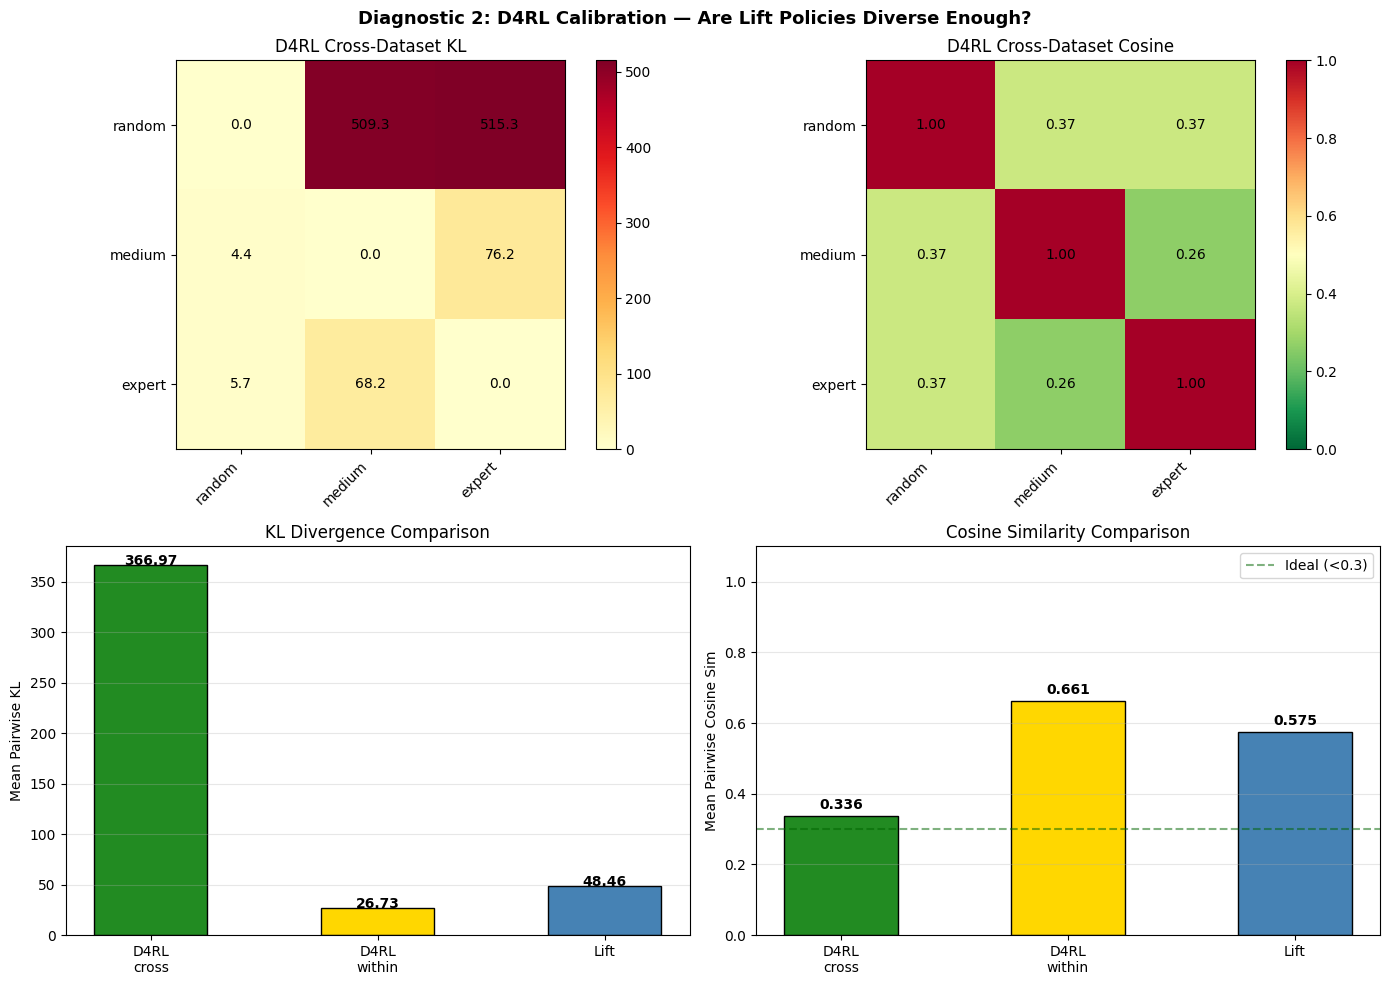

In [7]:
# ── D4RL Calibration: Visual comparison ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (mat, title, nms) in enumerate([
    (d4rl_cross_kl, "D4RL Cross-Dataset KL", d4rl_cross),
    (d4rl_cross_cos, "D4RL Cross-Dataset Cosine", d4rl_cross),
]):
    ax = axes[0, idx]
    cmap = "YlOrRd" if "KL" in title else "RdYlGn_r"
    vmax = mat.max() if "KL" in title else 1.0
    im = ax.imshow(mat, cmap=cmap, vmin=0, vmax=vmax)
    ax.set_xticks(range(len(nms))); ax.set_xticklabels(nms, rotation=45, ha="right")
    ax.set_yticks(range(len(nms))); ax.set_yticklabels(nms)
    for i in range(len(nms)):
        for j in range(len(nms)):
            fmt = f"{mat[i,j]:.1f}" if "KL" in title else f"{mat[i,j]:.2f}"
            ax.text(j, i, fmt, ha="center", va="center", fontsize=10)
    plt.colorbar(im, ax=ax)
    ax.set_title(title)

# Comparison bar chart: KL
ax = axes[1, 0]
settings = ["D4RL\ncross", "D4RL\nwithin", "Lift"]
kl_vals = [d4rl_cross_kl_mean, d4rl_within_kl_mean, lift_kl_mean]
colors = ["forestgreen", "gold", "steelblue"]
bars = ax.bar(settings, kl_vals, color=colors, edgecolor="black", width=0.5)
for b, v in zip(bars, kl_vals): ax.text(b.get_x()+b.get_width()/2, v+0.1, f"{v:.2f}",
                                         ha="center", fontweight="bold")
ax.set_ylabel("Mean Pairwise KL")
ax.set_title("KL Divergence Comparison")
ax.grid(True, alpha=0.3, axis="y")

# Comparison bar chart: Cosine
ax = axes[1, 1]
cos_vals = [d4rl_cross_cos_mean, d4rl_within_cos_mean, lift_cos_mean]
bars = ax.bar(settings, cos_vals, color=colors, edgecolor="black", width=0.5)
for b, v in zip(bars, cos_vals): ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.3f}",
                                          ha="center", fontweight="bold")
ax.set_ylabel("Mean Pairwise Cosine Sim")
ax.set_title("Cosine Similarity Comparison")
ax.set_ylim([0, 1.1])
ax.axhline(y=0.3, color="darkgreen", ls="--", alpha=0.5, label="Ideal (<0.3)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Diagnostic 2: D4RL Calibration — Are Lift Policies Diverse Enough?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Diagnostic 3: Action Marginal Overlap (Wasserstein-1)

For each policy, sample actions on the same test states, then compute per-dimension
Wasserstein-1 distance (Earth mover's distance) between action marginals.

W1 = 0 means identical distributions. Higher = more different.
Normalized by action std for cross-task comparison.

DIAGNOSTIC 3: Action Marginal Wasserstein-1 Distance

Lift BC_Gaussian:
  Mean W1: 0.0862 (range [0.0223, 0.1801])

D4RL cross-dataset:
  Mean W1: 0.2051 (range [0.1881, 0.2223])

D4RL within-dataset:
  Mean W1: 0.0784 (range [0.0432, 0.1083])

Normalized W1 (W1 / action_std):
  Lift:        0.3207 (act_std=0.2687)
  D4RL cross:  0.3440 (act_std=0.5963)
  D4RL within: 0.1315

Lift W1 matrix:
                    10d_e50  10d_e200  25d_e100  50d_e100  100d_e10  200d_e10
   10d_e50           0.0000    0.1801    0.1789    0.1617    0.1577    0.1606
   10d_e200          0.1801    0.0000    0.0223    0.0365    0.0379    0.0741
   25d_e100          0.1789    0.0223    0.0000    0.0307    0.0366    0.0768
   50d_e100          0.1617    0.0365    0.0307    0.0000    0.0273    0.0594
   100d_e100         0.1577    0.0379    0.0366    0.0273    0.0000    0.0521
   200d_e100         0.1606    0.0741    0.0768    0.0594    0.0521    0.0000


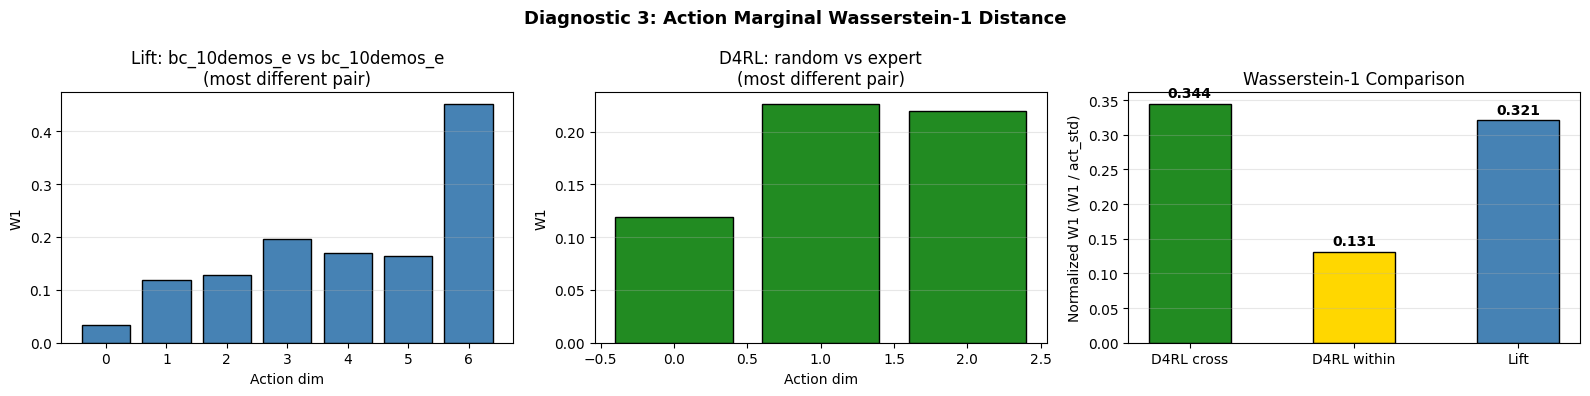

In [8]:
# ── Diagnostic 3: Wasserstein-1 per action dimension ──
def compute_w1_matrix(policy_names, policies, test_obs, act_dim, n_samples=1000, label=""):
    """Sample actions from each policy on same states, compute pairwise W1."""
    # Sample actions
    sampled = {}
    for name in policy_names:
        pol = policies[name]
        obs_rep = test_obs[:n_samples]
        acts = pol.sample_actions(obs_rep).cpu().numpy()
        sampled[name] = acts
    
    n = len(policy_names)
    w1_matrix = np.zeros((n, n))  # mean across dims
    w1_per_dim = {}  # (i,j) -> array of per-dim W1
    
    for i in range(n):
        for j in range(i+1, n):
            w1_dims = []
            for d in range(act_dim):
                w1 = wasserstein_distance(sampled[policy_names[i]][:, d],
                                           sampled[policy_names[j]][:, d])
                w1_dims.append(w1)
            w1_mean = np.mean(w1_dims)
            w1_matrix[i, j] = w1_mean
            w1_matrix[j, i] = w1_mean
            w1_per_dim[(i, j)] = np.array(w1_dims)
    
    off_diag = [w1_matrix[i,j] for i in range(n) for j in range(i+1, n)]
    print(f"\n{label}:")
    print(f"  Mean W1: {np.mean(off_diag):.4f} (range [{np.min(off_diag):.4f}, {np.max(off_diag):.4f}])")
    return w1_matrix, w1_per_dim, sampled, np.mean(off_diag)

print(f"{'='*80}")
print(f"DIAGNOSTIC 3: Action Marginal Wasserstein-1 Distance")
print(f"{'='*80}")

# Lift
lift_w1_mat, lift_w1_dims, lift_sampled, lift_w1_mean = \
    compute_w1_matrix(names, bc_policies, test_obs_t, ACTION_DIM, label="Lift BC_Gaussian")

# D4RL cross
d4rl_w1_mat_cross, d4rl_w1_dims_cross, d4rl_sampled_cross, d4rl_w1_cross_mean = \
    compute_w1_matrix(d4rl_cross, d4rl_policies, d4rl_test_obs, D4RL_ACT_DIM, label="D4RL cross-dataset")

# D4RL within
d4rl_w1_mat_within, d4rl_w1_dims_within, d4rl_sampled_within, d4rl_w1_within_mean = \
    compute_w1_matrix(d4rl_within, d4rl_policies, d4rl_test_obs, D4RL_ACT_DIM, label="D4RL within-dataset")

# Normalize by action std for fair comparison
lift_act_std = np.std(test_act_np, axis=0).mean()
d4rl_act_std = d4rl_data["medium"]["actions"].std(axis=0).mean()
print(f"\nNormalized W1 (W1 / action_std):")
print(f"  Lift:        {lift_w1_mean/lift_act_std:.4f} (act_std={lift_act_std:.4f})")
print(f"  D4RL cross:  {d4rl_w1_cross_mean/d4rl_act_std:.4f} (act_std={d4rl_act_std:.4f})")
print(f"  D4RL within: {d4rl_w1_within_mean/d4rl_act_std:.4f}")

# Pairwise table for Lift
print(f"\nLift W1 matrix:")
short = [n.replace("bc_", "").replace("demos_", "d_") for n in names]
print(f"   {'':>14}", end="")
for s in short: print(f" {s[:8]:>9}", end="")
print()
for i in range(n_pol):
    print(f"   {short[i]:<14}", end="")
    for j in range(n_pol):
        print(f" {lift_w1_mat[i,j]:>9.4f}", end="")
    print()

# Per-dim W1 for most different Lift pair
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Lift per-dim W1 for most different pair
ax = axes[0]
max_ij = max(lift_w1_dims.keys(), key=lambda k: lift_w1_dims[k].mean())
ax.bar(range(ACTION_DIM), lift_w1_dims[max_ij], color="steelblue", edgecolor="black")
ax.set_xlabel("Action dim")
ax.set_ylabel("W1")
ax.set_title(f"Lift: {names[max_ij[0]][:12]} vs {names[max_ij[1]][:12]}\n(most different pair)")
ax.grid(True, alpha=0.3, axis="y")

# D4RL cross per-dim W1 for random vs expert
ax = axes[1]
re_key = (0, 2)  # random vs expert
if re_key in d4rl_w1_dims_cross:
    ax.bar(range(D4RL_ACT_DIM), d4rl_w1_dims_cross[re_key], color="forestgreen", edgecolor="black")
ax.set_xlabel("Action dim")
ax.set_ylabel("W1")
ax.set_title(f"D4RL: random vs expert\n(most different pair)")
ax.grid(True, alpha=0.3, axis="y")

# Comparison bar
ax = axes[2]
settings = ["D4RL cross", "D4RL within", "Lift"]
w1_vals = [d4rl_w1_cross_mean/d4rl_act_std, d4rl_w1_within_mean/d4rl_act_std, lift_w1_mean/lift_act_std]
colors = ["forestgreen", "gold", "steelblue"]
bars = ax.bar(settings, w1_vals, color=colors, edgecolor="black", width=0.5)
for b, v in zip(bars, w1_vals): ax.text(b.get_x()+b.get_width()/2, v+0.01, f"{v:.3f}",
                                         ha="center", fontweight="bold")
ax.set_ylabel("Normalized W1 (W1 / act_std)")
ax.set_title("Wasserstein-1 Comparison")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Diagnostic 3: Action Marginal Wasserstein-1 Distance", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Diagnostic 4: Policy Identity Classifier

Given (state, action), predict which policy generated the action.

- Chance accuracy = 1/N_policies
- High accuracy = policies are easily distinguishable in (s,a) space
- This directly answers: "can you tell which policy produced this action?"

We train an MLP classifier on sampled (s, a) pairs from each policy, then test on held-out samples.

In [9]:
# ── Diagnostic 4: Policy Identity Classifier ──
def train_policy_classifier(policy_names, policies, test_obs, obs_dim, act_dim,
                             n_samples=2000, n_epochs=200, label=""):
    """Train MLP to classify which policy generated (s,a). Return test accuracy."""
    n_classes = len(policy_names)
    
    # Sample actions from each policy on the same states
    all_sa, all_labels = [], []
    for idx, name in enumerate(policy_names):
        pol = policies[name]
        obs_batch = test_obs[:n_samples]
        acts = pol.sample_actions(obs_batch).cpu()
        sa = torch.cat([obs_batch.cpu(), acts], dim=-1)  # (n_samples, obs+act)
        all_sa.append(sa)
        all_labels.append(torch.full((n_samples,), idx, dtype=torch.long))
    
    all_sa = torch.cat(all_sa, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    # Train/test split (80/20)
    N = len(all_sa)
    perm = torch.randperm(N)
    n_train = int(0.8 * N)
    train_sa, train_y = all_sa[perm[:n_train]].to(device), all_labels[perm[:n_train]].to(device)
    test_sa, test_y = all_sa[perm[n_train:]].to(device), all_labels[perm[n_train:]].to(device)
    
    # Simple MLP classifier
    classifier = nn.Sequential(
        nn.Linear(obs_dim + act_dim, 128), nn.ReLU(),
        nn.Linear(128, 128), nn.ReLU(),
        nn.Linear(128, n_classes),
    ).to(device)
    
    opt = torch.optim.Adam(classifier.parameters(), lr=1e-3)
    batch_size = 256
    
    for epoch in range(n_epochs):
        classifier.train()
        idx = torch.randperm(n_train, device=device)
        for start in range(0, n_train, batch_size):
            batch_idx = idx[start:start+batch_size]
            logits = classifier(train_sa[batch_idx])
            loss = F.cross_entropy(logits, train_y[batch_idx])
            opt.zero_grad(); loss.backward(); opt.step()
    
    # Evaluate
    classifier.eval()
    with torch.no_grad():
        test_logits = classifier(test_sa)
        test_preds = test_logits.argmax(dim=-1)
        accuracy = (test_preds == test_y).float().mean().item()
        
        # Per-class accuracy
        per_class_acc = []
        for c in range(n_classes):
            mask = test_y == c
            if mask.sum() > 0:
                per_class_acc.append((test_preds[mask] == c).float().mean().item())
            else:
                per_class_acc.append(0.0)
        
        # Confusion matrix
        confusion = torch.zeros(n_classes, n_classes)
        for c_true in range(n_classes):
            mask = test_y == c_true
            if mask.sum() > 0:
                for c_pred in range(n_classes):
                    confusion[c_true, c_pred] = (test_preds[mask] == c_pred).float().mean().item()
    
    chance = 1.0 / n_classes
    print(f"\n{label}:")
    print(f"  Overall accuracy: {accuracy:.1%} (chance: {chance:.1%})")
    for i, name in enumerate(policy_names):
        print(f"    {name:<20} {per_class_acc[i]:.1%}")
    
    return accuracy, per_class_acc, confusion.numpy(), chance

print(f"{'='*80}")
print(f"DIAGNOSTIC 4: Policy Identity Classifier")
print(f"{'='*80}")

# Lift classifier
lift_acc, lift_per_class, lift_confusion, lift_chance = \
    train_policy_classifier(names, bc_policies, test_obs_t, STATE_DIM, ACTION_DIM,
                             label="Lift BC_Gaussian (6 policies)")

# D4RL cross classifier
d4rl_cross_acc, d4rl_cross_per_class, d4rl_cross_confusion, d4rl_cross_chance = \
    train_policy_classifier(d4rl_cross, d4rl_policies, d4rl_test_obs, D4RL_OBS_DIM, D4RL_ACT_DIM,
                             label="D4RL cross-dataset (3 policies)")

# D4RL within classifier
d4rl_within_acc, d4rl_within_per_class, d4rl_within_confusion, d4rl_within_chance = \
    train_policy_classifier(d4rl_within, d4rl_policies, d4rl_test_obs, D4RL_OBS_DIM, D4RL_ACT_DIM,
                             label="D4RL within-dataset (3 policies)")

DIAGNOSTIC 4: Policy Identity Classifier



Lift BC_Gaussian (6 policies):
  Overall accuracy: 77.7% (chance: 16.7%)
    bc_10demos_e50       89.0%
    bc_10demos_e200      56.5%
    bc_25demos_e100      0.0%
    bc_50demos_e100      0.0%
    bc_100demos_e100     0.0%
    bc_200demos_e100     0.0%



D4RL cross-dataset (3 policies):
  Overall accuracy: 100.0% (chance: 33.3%)
    random               100.0%
    medium               0.0%
    expert               0.0%



D4RL within-dataset (3 policies):
  Overall accuracy: 100.0% (chance: 33.3%)
    medium_1k            100.0%
    medium_10k           0.0%
    medium_100k          0.0%


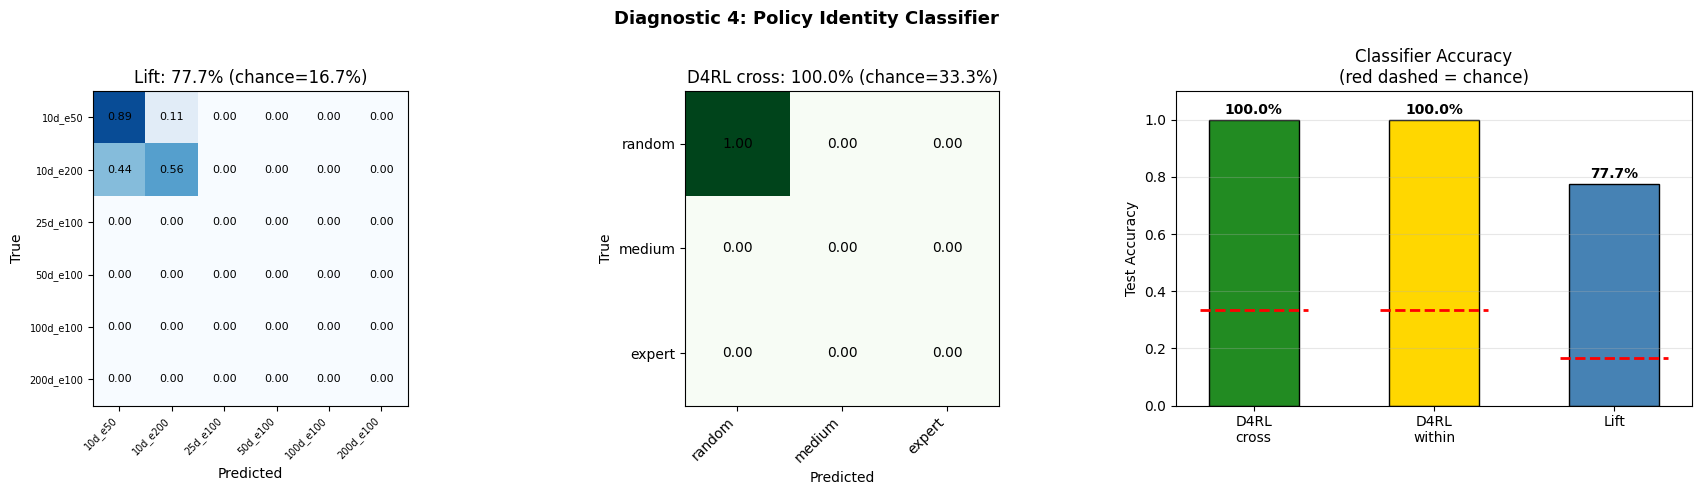

In [10]:
# ── Classifier visualization ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lift confusion matrix
ax = axes[0]
short = [n.replace("bc_", "").replace("demos_", "d_") for n in names]
im = ax.imshow(lift_confusion, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(n_pol)); ax.set_xticklabels(short, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(n_pol)); ax.set_yticklabels(short, fontsize=7)
for i in range(n_pol):
    for j in range(n_pol):
        ax.text(j, i, f"{lift_confusion[i,j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Lift: {lift_acc:.1%} (chance={lift_chance:.1%})")

# D4RL cross confusion
ax = axes[1]
n_d = len(d4rl_cross)
im = ax.imshow(d4rl_cross_confusion, cmap="Greens", vmin=0, vmax=1)
ax.set_xticks(range(n_d)); ax.set_xticklabels(d4rl_cross, rotation=45, ha="right")
ax.set_yticks(range(n_d)); ax.set_yticklabels(d4rl_cross)
for i in range(n_d):
    for j in range(n_d):
        ax.text(j, i, f"{d4rl_cross_confusion[i,j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"D4RL cross: {d4rl_cross_acc:.1%} (chance={d4rl_cross_chance:.1%})")

# Comparison bar chart
ax = axes[2]
settings = ["D4RL\ncross", "D4RL\nwithin", "Lift"]
accs = [d4rl_cross_acc, d4rl_within_acc, lift_acc]
chances = [d4rl_cross_chance, d4rl_within_chance, lift_chance]
colors = ["forestgreen", "gold", "steelblue"]

x = np.arange(len(settings))
bars = ax.bar(x, accs, color=colors, edgecolor="black", width=0.5)
# Chance lines
for i, (c, col) in enumerate(zip(chances, colors)):
    ax.plot([i-0.3, i+0.3], [c, c], color="red", ls="--", lw=2)
for b, v in zip(bars, accs):
    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.1%}", ha="center", fontweight="bold")

ax.set_xticks(x); ax.set_xticklabels(settings)
ax.set_ylabel("Test Accuracy")
ax.set_ylim([0, 1.1])
ax.set_title("Classifier Accuracy\n(red dashed = chance)")
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Diagnostic 4: Policy Identity Classifier", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary

v0.2.5.10: ACTION DISTRIBUTION DIVERSITY DIAGNOSTICS — SUMMARY

Metric                           D4RL cross   D4RL within         Lift
──────────────────────────────────────────────────────────────────────
Mean KL divergence                  366.969        26.729       48.462
Mean cosine similarity               0.3358        0.6610       0.5753
Normalized W1                        0.3440        0.1315       0.3207
Classifier accuracy                 100.0%       100.0%       77.7%
  (chance level)                     33.3%        33.3%       16.7%
──────────────────────────────────────────────────────────────────────

Lift / D4RL-cross ratios:
  KL ratio:         0.132x
  W1 ratio:         0.932x
  Classifier above chance:
    D4RL cross: 100.0% of max
    Lift:       73.2% of max

VERDICT:
  LIKELY INSUFFICIENT: Lift policies are significantly less diverse
  than D4RL cross-dataset, but not completely indistinguishable.
  Guidance may work with much stronger scaling or different appr

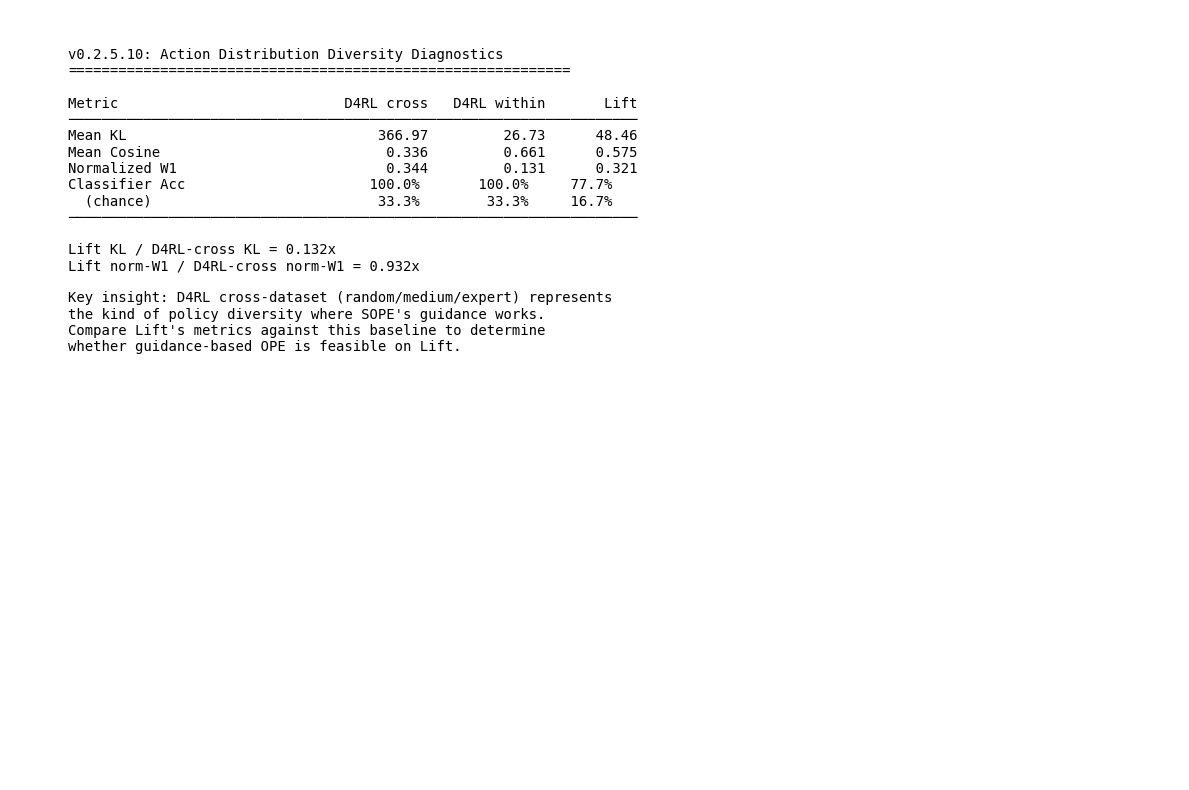

In [11]:
# ── Grand Summary ──
print(f"{'='*80}")
print(f"v0.2.5.10: ACTION DISTRIBUTION DIVERSITY DIAGNOSTICS — SUMMARY")
print(f"{'='*80}")

# Normalized metrics for fair comparison
lift_norm_w1 = lift_w1_mean / lift_act_std
d4rl_cross_norm_w1 = d4rl_w1_cross_mean / d4rl_act_std
d4rl_within_norm_w1 = d4rl_w1_within_mean / d4rl_act_std

print(f"\n{'Metric':<30} {'D4RL cross':>12} {'D4RL within':>13} {'Lift':>12}")
print(f"{'─'*70}")
print(f"{'Mean KL divergence':<30} {d4rl_cross_kl_mean:>12.3f} {d4rl_within_kl_mean:>13.3f} {lift_kl_mean:>12.3f}")
print(f"{'Mean cosine similarity':<30} {d4rl_cross_cos_mean:>12.4f} {d4rl_within_cos_mean:>13.4f} {lift_cos_mean:>12.4f}")
print(f"{'Normalized W1':<30} {d4rl_cross_norm_w1:>12.4f} {d4rl_within_norm_w1:>13.4f} {lift_norm_w1:>12.4f}")
print(f"{'Classifier accuracy':<30} {d4rl_cross_acc:>11.1%} {d4rl_within_acc:>12.1%} {lift_acc:>11.1%}")
print(f"{'  (chance level)':<30} {d4rl_cross_chance:>11.1%} {d4rl_within_chance:>12.1%} {lift_chance:>11.1%}")
print(f"{'─'*70}")

# Ratios
print(f"\nLift / D4RL-cross ratios:")
print(f"  KL ratio:         {lift_kl_mean / max(d4rl_cross_kl_mean, 1e-6):.3f}x")
print(f"  W1 ratio:         {lift_norm_w1 / max(d4rl_cross_norm_w1, 1e-6):.3f}x")
print(f"  Classifier above chance:")
lift_above = (lift_acc - lift_chance) / (1.0 - lift_chance)
d4rl_above = (d4rl_cross_acc - d4rl_cross_chance) / (1.0 - d4rl_cross_chance)
print(f"    D4RL cross: {d4rl_above:.1%} of max")
print(f"    Lift:       {lift_above:.1%} of max")

# Verdict
print(f"\n{'='*80}")
print("VERDICT:")
if lift_kl_mean < d4rl_cross_kl_mean * 0.1 and lift_acc < lift_chance * 2:
    print("  CONFIRMED: Lift action distributions are fundamentally too similar")
    print("  for guidance-based OPE. The problem is in the task/policies, not")
    print("  the guidance implementation.")
elif lift_kl_mean < d4rl_cross_kl_mean * 0.5:
    print("  LIKELY INSUFFICIENT: Lift policies are significantly less diverse")
    print("  than D4RL cross-dataset, but not completely indistinguishable.")
    print("  Guidance may work with much stronger scaling or different approach.")
else:
    print("  SURPRISING: Lift policies show comparable diversity to D4RL.")
    print("  The guidance implementation itself may be the bottleneck.")
print(f"{'='*80}")

# Text summary figure
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.axis("off")
lines = [
    "v0.2.5.10: Action Distribution Diversity Diagnostics",
    "=" * 60, "",
    f"{'Metric':<30} {'D4RL cross':>12} {'D4RL within':>13} {'Lift':>10}",
    "─" * 68,
    f"{'Mean KL':<30} {d4rl_cross_kl_mean:>12.2f} {d4rl_within_kl_mean:>13.2f} {lift_kl_mean:>10.2f}",
    f"{'Mean Cosine':<30} {d4rl_cross_cos_mean:>12.3f} {d4rl_within_cos_mean:>13.3f} {lift_cos_mean:>10.3f}",
    f"{'Normalized W1':<30} {d4rl_cross_norm_w1:>12.3f} {d4rl_within_norm_w1:>13.3f} {lift_norm_w1:>10.3f}",
    f"{'Classifier Acc':<30} {d4rl_cross_acc:>11.1%} {d4rl_within_acc:>12.1%} {lift_acc:>9.1%}",
    f"{'  (chance)':<30} {d4rl_cross_chance:>11.1%} {d4rl_within_chance:>12.1%} {lift_chance:>9.1%}",
    "─" * 68, "",
    f"Lift KL / D4RL-cross KL = {lift_kl_mean / max(d4rl_cross_kl_mean, 1e-6):.3f}x",
    f"Lift norm-W1 / D4RL-cross norm-W1 = {lift_norm_w1 / max(d4rl_cross_norm_w1, 1e-6):.3f}x", "",
    "Key insight: D4RL cross-dataset (random/medium/expert) represents",
    "the kind of policy diversity where SOPE's guidance works.",
    "Compare Lift's metrics against this baseline to determine",
    "whether guidance-based OPE is feasible on Lift.",
]
ax.text(0.05, 0.95, "\n".join(lines), transform=ax.transAxes,
        fontsize=10, verticalalignment="top", fontfamily="monospace")
plt.tight_layout()
plt.show()